# Discrete Choice Demand Model

In [1]:
from datetime import datetime
from io import StringIO
from itertools import product
import json
import os
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display, Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.linear_model import LogisticRegression
import scipy.stats

from phdtools import DATA_DIR, RESULTS_DIR
from phdtools.rdm import (
    DataID,
    DataType,
    Chapter,
    request_free_id,
    auto_create_path,
    write_metadata,
)
from phdtools.stats import ecdf

TODAY = datetime.today().strftime("%y%m%d")
FILE_DATE = os.getenv("FILE_DATE", "260321")

MAX_AGENTS = 1024
MAX_SAMPLE = 1024

SEED_AGENTS = os.getenv("SEED_AGENTS")
if SEED_AGENTS is not None:
    SEED_AGENTS = int(os.getenv("SEED_AGENTS"))

SEED_COEFFICIENTS = os.getenv("SEED_COEFFICIENTS")
if SEED_COEFFICIENTS is not None:
    SEED_COEFFICIENTS = int(os.getenv("SEED_COEFFICIENTS"))

SEED_REGRESSION = os.getenv("SEED_REGRESSION")
if SEED_REGRESSION is not None:
    SEED_REGRESSION = int(os.getenv("SEED_REGRESSION"))

overwrite = False
if overwrite:
    FILE_DATE = TODAY

In [2]:
!ls {DATA_DIR}

bafa-mastr                 nist-webbook
choi-stenger-2003          peters-2004
codata                     README.md
faber-valente-janssen-2010 rommel-sagebiel-2017
iapws-1995                 stba-2025
klinedinst-1974            uba-2016
macdonald-1969             xu-froment-1989
mendes-2010                zhang-2007
nist-janaf


## Table of Contents

- [Rommel and Sagebiel, 2017](#Rommel-and-Sagebiel,-2017:-Preferences-for-micro-cogeneration-in-Germany)
    - [Sampling](#Sampling)
      - [Socio-demographic attributes](#Socio-demographic-attributes)
      - [Coefficients](#Coefficients)
    - [Willingness-to-pay values](#Willingness-to-pay-values)  
    - [Choice probabilities](#Choice-probabilities)
        - [Variation over cost](#Variation-over-cost)
    - [Logit approximation](#Logit-approximation)
- [Oberst and Madlener, 2015](#Oberst-and-Madlener,-2015:-Prosumer-Preferences-Regarding-the-Adoption-of-Micro-Generation-Technologies)
- [References](#References)

## Rommel and Sagebiel, 2017: Preferences for micro-cogeneration in Germany

In [3]:
!ls {DATA_DIR / "rommel-sagebiel-2017"}

data_230420_RPL_Model_CHP_Table_4_Rommel_Sagebiel.csv


## Sampling
[back](#Table-of-Contents)

In [4]:
from phdtools.models.rommel_sagebiel_2017 import (
    create_socio_demographic_samples,
    create_coefficient_samples,
    NUM_AGENTS,
    SAMPLE_SIZE,
)

In [5]:
RESAMPLE = False
if RESAMPLE:
    data_id = request_free_id(DataType.SUPPORT, Chapter.METHODS)
else:
    data_id = DataID(DataType.SUPPORT, Chapter.METHODS, 1)

create_socio_demographic_samples(
    data_id,
    seed=SEED_AGENTS,
    sample_sizes=[2**n for n in range(1, int(np.log(MAX_AGENTS) / np.log(2)) + 1)],
    doc=r"Synthetic sample of socio-demographic and energy related variables; see \textcite{Rommel.2017a}",
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/gVHrJE' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [6]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)}

260321_socio_demographic_attributes_1024.csv
260321_socio_demographic_attributes_128.csv
260321_socio_demographic_attributes_16.csv
260321_socio_demographic_attributes_2.csv
260321_socio_demographic_attributes_256.csv
260321_socio_demographic_attributes_32.csv
260321_socio_demographic_attributes_4.csv
260321_socio_demographic_attributes_512.csv
260321_socio_demographic_attributes_64.csv
260321_socio_demographic_attributes_8.csv


In [7]:
if RESAMPLE:
    data_id = request_free_id(DataType.SUPPORT, Chapter.METHODS)
else:
    data_id = DataID(DataType.SUPPORT, Chapter.METHODS, 2)

create_coefficient_samples(
    data_id,
    seed=SEED_COEFFICIENTS,
    sample_sizes=[2**n for n in range(1, int(np.log(MAX_AGENTS) / np.log(2)) + 1)],
    doc=r"Mixed logit coefficients; see \textcite{Rommel.2017a}",
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/1d7OL3' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [8]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)}

260321_deterministic_coefficients.csv 260321_random_coefficients_32.csv
260321_random_coefficients_1024.csv   260321_random_coefficients_4.csv
260321_random_coefficients_128.csv    260321_random_coefficients_512.csv
260321_random_coefficients_16.csv     260321_random_coefficients_64.csv
260321_random_coefficients_2.csv      260321_random_coefficients_8.csv
260321_random_coefficients_256.csv


### Socio-demographic attributes

[back](#Table-of-Contents)

In [9]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)}

260321_socio_demographic_attributes_1024.csv
260321_socio_demographic_attributes_128.csv
260321_socio_demographic_attributes_16.csv
260321_socio_demographic_attributes_2.csv
260321_socio_demographic_attributes_256.csv
260321_socio_demographic_attributes_32.csv
260321_socio_demographic_attributes_4.csv
260321_socio_demographic_attributes_512.csv
260321_socio_demographic_attributes_64.csv
260321_socio_demographic_attributes_8.csv


In [10]:
from phdtools.models.rommel_sagebiel_2017 import MEAN_AGE, MEAN_FLATSIZE

socio_demographic_attributes = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
        / f"{FILE_DATE}_socio_demographic_attributes_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)

s = socio_demographic_attributes.copy()

# All interactions except the two binary variables sex and heating system were demeaned,
#   so that the main effects can be interpreted for the sample mean of these variables.
s["AGE"] = s["AGE"] + MEAN_AGE
s["FLATSIZE"] = s["FLATSIZE"] + MEAN_FLATSIZE

s.describe().T[["count", "mean", "50%", "std", "min", "max"]]

,count,mean,50%,std,min,max
AGE,512.0,48.712561,48.094840,17.325834,18.0,91.000000
SEX,512.0,0.478516,0.000000,0.500027,0.0,1.000000
INCOME,512.0,6.778885,6.717639,3.680614,1.0,13.000000
ENECOST,512.0,3.577367,3.592214,1.361339,1.0,6.000000
FLATSIZE,512.0,92.004986,91.357056,36.502072,12.0,206.292045
HEATSYS,512.0,0.431641,0.000000,0.495789,0.0,1.000000


### Coefficients

[back](#Table-of-Contents)

In [11]:
random_coefficients = pd.read_csv(
    DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
    comment="#",
    index_col=0,
)
deterministic_coefficients = pd.read_csv(
    DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_deterministic_coefficients.csv",
    comment="#",
    index_col=0,
).iloc[:, 0]

random_coefficients.describe()

,ITYPE,DUR,CO2SAV,CSAV,FIT,ICOST,ERR_COMP
count,512.000000,512.000000,512.000000,512.000000,512.000000,512.000000,512.000000
mean,-0.149175,-0.062934,0.111067,0.034878,0.042712,-0.270539,-0.000696
std,1.474556,0.163493,0.218631,0.028415,0.191030,0.235092,2.201741
min,-4.890145,-0.629797,-0.538764,-0.060760,-0.558930,-2.252006,-6.719307
25%,-1.138537,-0.172653,-0.036935,0.015733,-0.085677,-0.338709,-1.481173
50%,-0.146812,-0.062819,0.110791,0.034875,0.042698,-0.203319,0.003399
75%,0.842504,0.047125,0.258822,0.054026,0.171268,-0.122184,1.480597
max,4.365420,0.463445,0.754965,0.117429,0.633893,-0.019642,6.529248


In [12]:
deterministic_coefficients

coefficient
ASC               -2.226000
ITYPE x AGE       -0.017400
DUR x SEX          0.077700
CO2SAV x AGE      -0.006240
CSAV x AGE        -0.000459
FIT x SEX         -0.072100
FIT x FLATSIZE     0.001850
ICOST x HEATSYS    0.106000
Name: deterministic coefficients, dtype: float64

In [13]:
out = widgets.Output()

dropdown = widgets.Dropdown(
    options=random_coefficients.columns.tolist(),
    value=random_coefficients.columns[0],
    description="Variable:",
)


def plot_ecdf(change):
    with out:
        out.clear_output(wait=True)
        name = change["new"]
        x, y = ecdf(random_coefficients[name].to_numpy())
        fig, ax = plt.subplots()
        _ = ax.plot(x, y, "k.")
        _ = ax.set_xlabel(rf"$\beta_\mathrm{{{change['new']}}}$")
        _ = ax.set_ylabel(
            rf"Probability $\Pr(\tilde{{\beta}}_\mathrm{{{change['new']}}} \leq \beta_\mathrm{{{change['new']}}})$"
        )
        _ = ax.set_title(rf"ECDF of $\tilde{{\beta}}_\mathrm{{{change['new']}}}$")
        _ = plt.grid(True)
        plt.close()
        display(fig)


# Register callback
dropdown.observe(plot_ecdf, names="value")

In [14]:
# Initial plot
with out:
    name = dropdown.value
    x, y = ecdf(random_coefficients[name].to_numpy())
    fig, ax = plt.subplots()
    _ = ax.plot(x, y, "k.")
    _ = ax.set_xlabel(rf"$\beta_\mathrm{{{dropdown.value}}}$")
    _ = ax.set_ylabel(
        rf"Probability $\Pr(\tilde{{\beta}}_\mathrm{{{dropdown.value}}} \leq \beta_\mathrm{{{dropdown.value}}})$"
    )
    _ = ax.set_title(rf"ECDF of $\tilde{{\beta}}_\mathrm{{{dropdown.value}}}$")
    _ = plt.grid(True)
    _ = plt.close()
    display(fig)

# Display controls and output
display(dropdown)
display(out)

Dropdown(description='Variable:', options=('ITYPE', 'DUR', 'CO2SAV', 'CSAV', 'FIT', 'ICOST', 'ERR_COMP'), valu…

Output()

## Willingness-to-pay values
[back](#Table-of-Contents)

$$
\mathrm{WTP}^{(r)}_k = 
\begin{cases} 
    \frac{
        \beta^{(r)}_k
    }{
        \beta^{(r)}_{\mathrm{ICOST}} + \alpha_{\mathrm{ICOST}\times\mathrm{HEATSYS}}\,\mathrm{HEATSYS}
    }, \text{without interaction} \\
    \frac{
        \beta^{(r)}_k + \alpha_{k \times x}\,x
    }{
        \beta^{(r)}_{\mathrm{ICOST}} + \alpha_{\mathrm{ICOST}\times\mathrm{HEATSYS}}\,\mathrm{HEATSYS}
    }, \text{with interaction term} \ k \times x
\end{cases}
$$

### Recreate Table 5 for verification

In [15]:
import io
from phdtools.models.rommel_sagebiel_2017 import recreate_table5_rommel2017

with io.StringIO() as ostream:
    recreate_table5_rommel2017(
        ostream,
        fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
        / f"{FILE_DATE}_deterministic_coefficients.csv",
        fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
        / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
        fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
        / f"{FILE_DATE}_socio_demographic_attributes_{NUM_AGENTS}.csv",
    )
    print(ostream.getvalue())

------------------+--------------------+--------------------+--------------------+-------------------
Attribute         | Socio-demographics | WTP(HEATSYS = 0)   | WTP(HEATSYS = 1)   | Average WTP       
------------------+--------------------+--------------------+--------------------+-------------------
ASC               | ASC                |            10948.3 |            22873.1 |            16095.5
------------------+--------------------+--------------------+--------------------+-------------------
Investment type   | ITYPE60y           |             1693.4 |             3537.9 |             1042.2
                  | ITYPE25y           |            -1301.9 |            -2719.9 |                nan
------------------+--------------------+--------------------+--------------------+-------------------
Contract duration | DURFemale          |              309.0 |              645.5 |              182.7
                  | DURMale            |              -73.2 |             -152.9 |

In [16]:
import io
from phdtools.models.rommel_sagebiel_2017 import recreate_table5_rommel2017

with io.StringIO() as ostream:
    recreate_table5_rommel2017(
        ostream,
        fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
        / f"{FILE_DATE}_deterministic_coefficients.csv",
        fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
        / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
        fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
        / f"{FILE_DATE}_socio_demographic_attributes_{NUM_AGENTS}.csv",
    )
    print(ostream.getvalue())

------------------+--------------------+--------------------+--------------------+-------------------
Attribute         | Socio-demographics | WTP(HEATSYS = 0)   | WTP(HEATSYS = 1)   | Average WTP       
------------------+--------------------+--------------------+--------------------+-------------------
ASC               | ASC                |            10948.3 |            22873.1 |            16095.5
------------------+--------------------+--------------------+--------------------+-------------------
Investment type   | ITYPE60y           |             1693.4 |             3537.9 |             1042.2
                  | ITYPE25y           |            -1301.9 |            -2719.9 |                nan
------------------+--------------------+--------------------+--------------------+-------------------
Contract duration | DURFemale          |              309.0 |              645.5 |              182.7
                  | DURMale            |              -73.2 |             -152.9 |

### Correct median values

In [17]:
from phdtools.models.rommel_sagebiel_2017 import wtp, median_wtp

attr = "ASC"
z1 = wtp(
    attr,
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
    heatsys=0,
)
z2 = wtp(
    attr,
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
    heatsys=1,
)

x1, y1 = ecdf(z1)
x2, y2 = ecdf(z2)
m1, m2 = median_wtp(
    "ASC",
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
    heatsys=0,
), median_wtp(
    "ASC",
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
    heatsys=1,
)

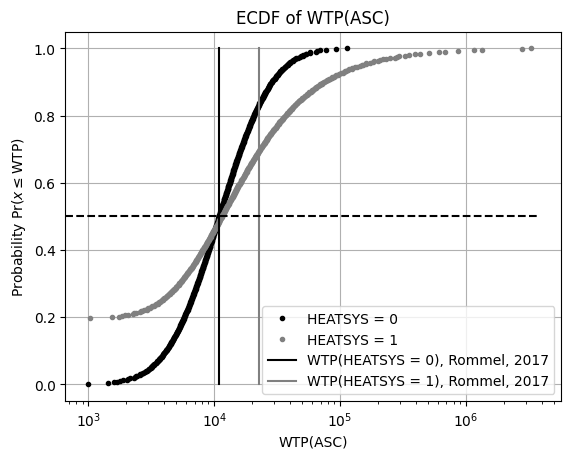

In [18]:
fig, ax = plt.subplots()

# WTP distribution
_ = ax.plot(x1, y1, "k.", label="HEATSYS = 0")
_ = ax.plot(x2, y2, ".", color="gray", label="HEATSYS = 1")

# wrong medians, computed by Rommel
_ = ax.plot([m1, m1], [0, 1], color="black", label="WTP(HEATSYS = 0), Rommel, 2017")
_ = ax.plot([m2, m2], [0, 1], color="gray", label="WTP(HEATSYS = 1), Rommel, 2017")

# help line
xmin, xmax = ax.get_xlim()
_ = ax.plot([xmin, xmax], [0.5, 0.5], "k--")

_ = ax.set_xlabel(f"WTP({attr})")
_ = ax.set_ylabel(r"Probability $\Pr(x \leq \mathrm{WTP})$")
_ = ax.set_title(f"ECDF of WTP({attr})")
_ = plt.grid(True)
_ = ax.semilogx()
_ = ax.legend()

In [19]:
with io.StringIO() as ostream:
    recreate_table5_rommel2017(
        ostream,
        fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
        / f"{FILE_DATE}_deterministic_coefficients.csv",
        fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
        / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
        fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
        / f"{FILE_DATE}_socio_demographic_attributes_{NUM_AGENTS}.csv",
        wtp_func=lambda *args, **kwargs: np.median(
            wtp(*args, **kwargs).dropna(), axis=0
        ),
    )
    print(ostream.getvalue())

------------------+--------------------+--------------------+--------------------+-------------------
Attribute         | Socio-demographics | WTP(HEATSYS = 0)   | WTP(HEATSYS = 1)   | Average WTP       
------------------+--------------------+--------------------+--------------------+-------------------
ASC               | ASC                |            10948.3 |            11520.2 |            10657.2
------------------+--------------------+--------------------+--------------------+-------------------
Investment type   | ITYPE60y           |             1352.4 |             1213.3 |              815.0
                  | ITYPE25y           |            -1084.5 |             -677.9 |                nan
------------------+--------------------+--------------------+--------------------+-------------------
Contract duration | DURFemale          |              237.8 |              128.9 |               31.3
                  | DURMale            |              -56.8 |             -112.0 |

## Choice probabilities

[back](#Table-of-Contents)

In [20]:
socio_demographic_attributes.head()

,AGE,SEX,INCOME,ENECOST,FLATSIZE,HEATSYS
AGENT,,,,,,
1,-0.686915,1.0,5.936747,5.462605,3.995953,0.0
2,7.647766,0.0,8.996448,1.575068,-47.574470,0.0
3,21.894041,0.0,12.923828,3.496826,21.312876,0.0
4,-6.370434,1.0,2.160134,1.845732,37.551127,1.0
5,14.804543,0.0,8.331923,3.701433,7.664988,0.0


In [21]:
attributes_alternative = pd.DataFrame(
    columns=["ITYPE", "ICOST", "DUR", "CO2SAV", "CSAV", "FIT"], dtype=float
)

attributes_alternative.loc[1, "ITYPE"] = 0  # binary
attributes_alternative.loc[1, "ICOST"] = 25  # WTP of the ASC is given in Euro
attributes_alternative.loc[1, "DUR"] = 5  # WTP is given in Euro per year
attributes_alternative.loc[1, "CO2SAV"] = 0.25 * 10  # WTP is given in Euro per 10%
attributes_alternative.loc[1, "CSAV"] = 0.2 * 100  # WTP is given in Euro per 1%
attributes_alternative.loc[1, "FIT"] = 8  # WTP is given in Euro per Eurocent
attributes_alternative.index.name = "ALTERNATIVE"

index = pd.MultiIndex.from_product(
    [socio_demographic_attributes.index, attributes_alternative.index],
    names=["AGENT", "ALTERNATIVE"],
)
attributes_alternative = attributes_alternative.reindex(index, level="ALTERNATIVE")
attributes_alternative

,,ITYPE,ICOST,DUR,CO2SAV,CSAV,FIT
AGENT,ALTERNATIVE,,,,,,
1,1,0.0,25.0,5.0,2.5,20.0,8.0
2,1,0.0,25.0,5.0,2.5,20.0,8.0
3,1,0.0,25.0,5.0,2.5,20.0,8.0
4,1,0.0,25.0,5.0,2.5,20.0,8.0
5,1,0.0,25.0,5.0,2.5,20.0,8.0
...,...,...,...,...,...,...,...
508,1,0.0,25.0,5.0,2.5,20.0,8.0
509,1,0.0,25.0,5.0,2.5,20.0,8.0
510,1,0.0,25.0,5.0,2.5,20.0,8.0


In [22]:
from phdtools.models.rommel_sagebiel_2017 import compute_interactions, mxl_prob

interactions = compute_interactions(
    attributes_alternative,
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE}_socio_demographic_attributes_{NUM_AGENTS}.csv",
)
interactions

,,ICOST x HEATSYS,CO2SAV x AGE,CSAV x AGE,ITYPE x AGE,DUR x SEX,FIT x SEX,FIT x FLATSIZE
AGENT,ALTERNATIVE,,,,,,,
1,1,0.0,-1.717288,-13.738304,-0.0,5.0,8.0,31.967625
2,1,0.0,19.119415,152.955322,0.0,0.0,0.0,-380.595762
3,1,0.0,54.735103,437.880828,0.0,0.0,0.0,170.503007
4,1,25.0,-15.926086,-127.408685,-0.0,5.0,8.0,300.409014
5,1,0.0,37.011357,296.090859,0.0,0.0,0.0,61.319903
...,...,...,...,...,...,...,...,...
508,1,25.0,5.373635,42.989082,0.0,0.0,0.0,-150.233090
509,1,0.0,-30.368699,-242.949593,-0.0,0.0,0.0,-133.468681
510,1,0.0,19.541386,156.331085,0.0,5.0,8.0,-5.687472


In [23]:
probability = mxl_prob(
    attributes_alternative,
    interactions,
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
)
probability

ALTERNATIVE,1
AGENT,
1,0.304699
2,0.245366
3,0.295703
4,0.557335
5,0.293655
...,...
508,0.495160
509,0.317819
510,0.282898


#### Variation over cost
[back](#Table-of-Contents)

In [24]:
from itertools import product
from phdtools.models.rommel_sagebiel_2017 import compute_sample_avg_mxl_prob

In [25]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 6)


@auto_create_path
def save_mxl_sample_avg_prob_vs_icost(path, fname_a, fname_b, fname_s):

    # design-related attributes
    icost = np.arange(10, 31, 1)
    csav = np.array([0, 0.1, 0.2]) * 100
    co2sav = np.array([0.0, 0.1, 0.2]) * 10

    # non design-related attributes
    itype = np.array([0])
    dur = np.array([5])
    fit = np.array([8])

    attributes_alternative = pd.DataFrame(
        product(itype, icost, dur, co2sav, csav, fit),
        columns=["ITYPE", "ICOST", "DUR", "CO2SAV", "CSAV", "FIT"],
    )
    attributes_alternative.index.name = "ALTERNATIVE"

    socio_demographic_attributes = pd.read_csv(
        fname_s,
        comment="#",
        index_col=0,
    )

    index = pd.MultiIndex.from_product(
        [socio_demographic_attributes.index, attributes_alternative.index],
        names=["AGENT", "ALTERNATIVE"],
    )
    attributes_alternative = attributes_alternative.reindex(index, level="ALTERNATIVE")

    _tmp = compute_sample_avg_mxl_prob(
        attributes_alternative, fname_a, fname_b, fname_s
    )

    frame = (
        attributes_alternative.join(_tmp, on="ALTERNATIVE", how="right")
        .droplevel("AGENT")
        .drop_duplicates()
    )

    mask = (
        (frame["CSAV"] == 20.0)
        & (frame["ITYPE"] == 0)
        & (frame["DUR"] == 5)
        & (frame["FIT"] == 8)
    )

    description = (
        "Sample average choice probability according to\n"
        "a mixed logit model by Rommel and Sagebiel (2017).\n"
        "Probabilities computed over values of ICOST for different\n"
        "values of CO2SAV ("
        "CSAV={}, ITYPE={}, DUR={}, FIT={}).\n".format(20.0, 0, 5, 8)
        + "The results are based on an synthetic sample of decision makers\n"
        "characterized by socio-demographic attributes and realizations of\n"
        "the random coefficients to compute the mean probability for every\n"
        "decision-maker.\n\n"
        "The random coeficients are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_b.relative_to(RESULTS_DIR))
        + "The socio-demographic attributes are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_s.relative_to(RESULTS_DIR))
        + (
            "\n"
            "References:\n"
            "-----------\n"
            "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            "    Germany: Policy implications for grid expansion from a discrete choice\n"
            "    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            "    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
        )
    )

    fname = path / f"{TODAY}_mxl_sample_avg_prob_co2sav_rommel2017.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        header = "ICOST," + ",".join(f"CO2SAV={val:2.1f}" for val in co2sav)
        f.write(header)
        f.write("\n")
        frame[mask].pivot(
            index="ICOST", columns="CO2SAV", values="SAMPLE_AVG_MXL_PROB"
        ).to_csv(f, index=True, header=False)

    mask = (
        (frame["CO2SAV"] == 2.0)
        & (frame["ITYPE"] == 0)
        & (frame["DUR"] == 5)
        & (frame["FIT"] == 8)
    )

    description = (
        "Sample average choice probability according to\n"
        "a mixed logit model by Rommel and Sagebiel (2017).\n"
        "Probabilities computed over values of ICOST for different\n"
        "values of CSAV ("
        "CO2SAV={}, ITYPE={}, DUR={}, FIT={}).\n".format(2.0, 0, 5, 8)
        + "The results are based on an synthetic sample of decision makers\n"
        "characterized by socio-demographic attributes and realizations of\n"
        "the random coefficients to compute the mean probability for every\n"
        "decision-maker.\n\n"
        "The random coeficients are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_b.relative_to(RESULTS_DIR))
        + "The socio-demographic attributes are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_s.relative_to(RESULTS_DIR))
        + (
            "\n"
            "References:\n"
            "-----------\n"
            "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            "    Germany: Policy implications for grid expansion from a discrete choice\n"
            "    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            "    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
        )
    )

    fname = path / f"{TODAY}_mxl_sample_avg_prob_csav_rommel2017.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        header = "ICOST," + ",".join(f"CSAV={val:2.1f}" for val in csav)
        f.write(header)
        f.write("\n")
        frame[mask].pivot(
            index="ICOST", columns="CSAV", values="SAMPLE_AVG_MXL_PROB"
        ).to_csv(f, index=True, header=False)


save_mxl_sample_avg_prob_vs_icost(
    data_id,
    doc=r"Sample average choice probabilities according the model by \textcite{Rommel.2017a} w/o attribute variation",
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE}_socio_demographic_attributes_{NUM_AGENTS}.csv",
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/YBExTf' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [26]:
!ls {data_id.get_path(fail_exists=False)}

260321_mxl_sample_avg_prob_co2sav_rommel2017.csv
260321_mxl_sample_avg_prob_csav_rommel2017.csv


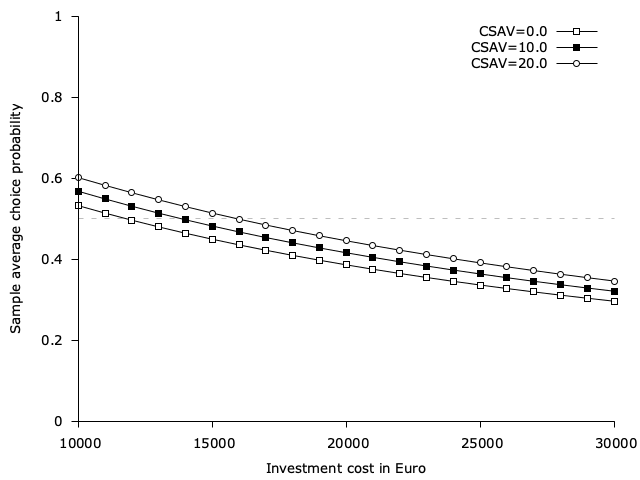

In [27]:
fname = (
    data_id.get_path(fail_exists=False)
    / f"{FILE_DATE}_mxl_sample_avg_prob_csav_rommel2017.csv"
)
os.makedirs("plots", exist_ok=True)
!gnuplot -e "filename='{fname}'; call 'plot_250629_sample_avg_prob.gnu'"
Image("plots/250629_SampleAvgProb.png")

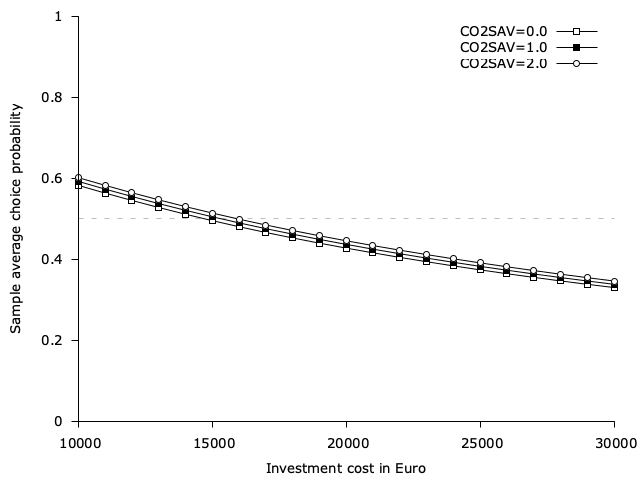

In [28]:
fname = (
    data_id.get_path(fail_exists=False)
    / f"{FILE_DATE}_mxl_sample_avg_prob_co2sav_rommel2017.csv"
)
os.makedirs("plots", exist_ok=True)
!gnuplot -e "filename='{fname}'; call 'plot_250629_sample_avg_prob.gnu'"
Image("plots/250629_SampleAvgProb.png")

### Logit approximation
[back](#Table-of-Contents)

In [29]:
# design-related attributes
icost = np.array([7.5, 10, 12.5])
csav = np.array([0.25, 0.5, 0.75]) * 100
co2sav = np.array([0.1, 0.2, 0.3]) * 10

# non design-related attributes
itype = np.array([0, 1])
dur = np.array([5, 10])
fit = np.array([4, 7, 10])

socio_demographic_attributes = pd.read_csv(
    (
        DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
        / f"{FILE_DATE}_socio_demographic_attributes_{NUM_AGENTS}.csv"
    ).as_posix(),
    comment="#",
    index_col=0,
)

attributes_alternative = pd.DataFrame(
    product(itype, icost, dur, co2sav, csav, fit),
    columns=["ITYPE", "ICOST", "DUR", "CO2SAV", "CSAV", "FIT"],
)
attributes_alternative.index.name = "ALTERNATIVE"

index = pd.MultiIndex.from_product(
    [socio_demographic_attributes.index, attributes_alternative.index],
    names=["AGENT", "ALTERNATIVE"],
)
attributes_alternative = attributes_alternative.reindex(index, level="ALTERNATIVE")

interactions = compute_interactions(
    attributes_alternative,
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE}_socio_demographic_attributes_{NUM_AGENTS}.csv",
)

probability = mxl_prob(
    attributes_alternative,
    interactions,
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
)
p = probability.stack()
p.name = "PROBABILITY"
p.head()

AGENT  ALTERNATIVE
1      0              0.645965
       1              0.631672
       2              0.615894
       3              0.719109
       4              0.703645
Name: PROBABILITY, dtype: float64

In [30]:
# AGENT  ALTERNATIVE
# 1      0              0.644136
#        1              0.632343
#        2              0.619836
#        3              0.719143
#        4              0.706726
# Name: PROBABILITY, dtype: float64

In [31]:
X_train = pd.concat([attributes_alternative, interactions], axis=1)
X_train["ASC"] = -1
X_train.head()

ITYPE  ICOST  DUR  CO2SAV  CSAV  FIT  ICOST x HEATSYS  \
AGENT ALTERNATIVE                                                          
1     0                0    7.5    5     1.0  25.0    4              0.0   
      1                0    7.5    5     1.0  25.0    7              0.0   
      2                0    7.5    5     1.0  25.0   10              0.0   
      3                0    7.5    5     1.0  50.0    4              0.0   
      4                0    7.5    5     1.0  50.0    7              0.0   

                   CO2SAV x AGE  CSAV x AGE  ITYPE x AGE  DUR x SEX  \
AGENT ALTERNATIVE                                                     
1     0               -0.686915  -17.172880         -0.0        5.0   
      1               -0.686915  -17.172880         -0.0        5.0   
      2               -0.686915  -17.172880         -0.0        5.0   
      3               -0.686915  -34.345761         -0.0        5.0   
      4               -0.686915  -34.345761         -0.0        5.0   

                   FIT x SEX  FIT x FLATSIZE  ASC  
AGENT ALTERNATIVE                                  
1     0                  4.0       15.983812   -1  
      1                  7.0       27.971672   -1  
      2                 10.0       39.959531   -1  
      3                  4.0       15.983812   -1  
      4                  7.0       27.971672   -1

### Option 1: Simulating choice outcomes

In [32]:
rng = np.random.default_rng(0)
y = pd.Series(rng.binomial(1, p.to_numpy()), index=p.index, name="CHOICE")
y.head()

AGENT  ALTERNATIVE
1      0              1
       1              1
       2              1
       3              1
       4              0
Name: CHOICE, dtype: int64

In [33]:
from numpy.random import RandomState
from sklearn.linear_model import LogisticRegression


def fit_logit_approximation(fname_a, fname_b, fname_s, random_state=None):

    # design-related attributes
    icost = np.array([7.5, 10, 12.5, 15, 17.5, 20, 22.5, 25, 27.5, 30])
    csav = np.array([0.1, 0.2, 0.3]) * 100  # improves the fit
    # csav = np.array([0.25, 0.5, 0.75]) * 100
    co2sav = np.array([0.1, 0.2, 0.3]) * 10

    # non design-related attributes
    itype = np.array([0, 1])
    dur = np.array([5, 10])
    fit = np.array([4, 7, 10])

    socio_demographic_attributes = pd.read_csv(
        fname_s,
        comment="#",
        index_col=0,
    )

    attributes_alternative = pd.DataFrame(
        product(itype, icost, dur, co2sav, csav, fit),
        columns=["ITYPE", "ICOST", "DUR", "CO2SAV", "CSAV", "FIT"],
    )
    attributes_alternative.index.name = "ALTERNATIVE"

    index = pd.MultiIndex.from_product(
        [s.index, attributes_alternative.index], names=["AGENT", "ALTERNATIVE"]
    )
    attributes_alternative = attributes_alternative.reindex(index, level="ALTERNATIVE")

    interactions = compute_interactions(attributes_alternative, fname_s)

    probability = mxl_prob(attributes_alternative, interactions, fname_a, fname_b)
    p = probability.stack()
    p.name = "PROBABILITY"

    X_train = pd.concat([attributes_alternative, interactions], axis=1)
    X_train["ASC"] = -1

    rng = np.random.default_rng(0)
    y = pd.Series(rng.binomial(1, p.to_numpy()), index=p.index, name="CHOICE")

    model = LogisticRegression(
        max_iter=5000, fit_intercept=False, random_state=random_state
    )
    res = model.fit(
        X_train.to_numpy(),
        y.to_numpy(),
    )

    logit_coefs = pd.Series(res.coef_[0], index=X_train.columns, name="Logit")

    return logit_coefs

In [34]:
data_id = DataID(DataType.SUPPORT, Chapter.METHODS, 3)


@auto_create_path
def save_logit_approximation(path, fname_a, fname_b, fname_s, seed=None):

    description = (
        "Logit approximation of Rommel and Sagebiel (2017).\n"
        "The model was fitted to simulated choice data using sklearl.linear_model.LogisticRegression\n"
        f"(scikit-learn {sklearn.__version__}).\n"
        f"The choice data were obtained by calculating the MXL choice probabilities Pn for N = {NUM_AGENTS}\n"
        f"different decision makers n and M = {SAMPLE_SIZE} realizations of the random coefficients\n"
        "for different combinations of factor levels of the alternatives and determining the choice outcome\n"
        "from a Bernoulli trial with probability Pn.\n"
        "\n"
        "References\n"
        "-----------\n"
        "Peters (2004): Plant design and economics for chemical engineers.\n"
        "    5. ed, international ed. 2004. Boston: McGraw-Hill (McGraw-Hill\n"
        "    chemical engineering series).\n\n"
        "Virtanen, P. et al. (2020) “SciPy 1.0: fundamental algorithms for scientific\n"
        "    computing in Python,” Nature Methods, 17(3), pp. 261–272. Available at:\n"
        "    https://doi.org/10.1038/s41592-019-0686-2.\n\n"
        "Pedregosa, F. et al. (2011) “Scikit-learn: Machine learning in Python,” Journal\n"
        "    of Machine Learning Research, 12, pp. 2825–2830.\n"
    )

    logit_coefs = fit_logit_approximation(
        fname_a, fname_b, fname_s, random_state=RandomState(seed=seed)
    )

    data_dict = logit_coefs.to_dict()
    with open(path / "METADATA.txt", "w") as f:
        write_metadata(f, description)
        # data_dict["_metadata"] = f.getvalue()

    fname = path / f"{TODAY}_logit_coefficients.json"
    with open(fname, "w") as f:
        json.dump(data_dict, f, indent=4)


save_logit_approximation(
    data_id,
    doc=r"Coefficients of the logit approximation of \textcite{Rommel.2017a}",
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE}_socio_demographic_attributes_{NUM_AGENTS}.csv",
    seed=SEED_REGRESSION,
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/KQ5GQN' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


#### Coefficients

In [35]:
!ls {DataID(DataType.SUPPORT,Chapter.METHODS, 3).get_path(fail_exists=False)}

260321_logit_coefficients.json METADATA.txt


In [36]:
logit_coefs = pd.read_json(
    DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
    / f"{FILE_DATE}_logit_coefficients.json",
    typ="series",
)
logit_coefs

ITYPE             -0.067952
ICOST             -0.071492
DUR               -0.023372
CO2SAV             0.037131
CSAV               0.012485
FIT                0.013671
ICOST x HEATSYS    0.035600
CO2SAV x AGE      -0.002383
CSAV x AGE        -0.000163
ITYPE x AGE       -0.005904
DUR x SEX          0.026499
FIT x SEX         -0.024304
FIT x FLATSIZE     0.000636
ASC               -0.656150
dtype: float64

In [37]:
# ITYPE             -0.068511
# ICOST             -0.070102
# DUR               -0.024925
# CO2SAV             0.039791
# CSAV               0.011495
# FIT                0.013238
# ICOST x HEATSYS    0.034319
# CO2SAV x AGE      -0.002279
# CSAV x AGE        -0.000144
# ITYPE x AGE       -0.006067
# DUR x SEX          0.025688
# FIT x SEX         -0.023583
# FIT x FLATSIZE     0.000619
# ASC               -0.679863

In [38]:
!ls {DATA_DIR / "rommel-sagebiel-2017"}

data_230420_RPL_Model_CHP_Table_4_Rommel_Sagebiel.csv


In [39]:
fname = (
    DATA_DIR
    / "rommel-sagebiel-2017"
    / "data_230420_RPL_Model_CHP_Table_4_Rommel_Sagebiel.csv"
)

mxl_coefs = pd.read_csv(
    fname,
    usecols=[0, 1, 3],
    skiprows=[0, 16, 17, 18, 19],
    index_col=0,
    names=["index", "Mixed logit (loc)", "Mixed logit (scale)"],
).reset_index()
coefs = (
    logit_coefs.reset_index()
    .merge(mxl_coefs, on="index", how="right")
    .set_index("index")
)
coefs.index.name = "Coefficient"
coefs

,0,Mixed logit (loc),Mixed logit (scale)
Coefficient,,,
ASC,-0.656150,-2.226000,NaN
ITYPE,-0.067952,-0.148000,1.4740
ITYPE x AGE,-0.005904,-0.017400,NaN
DUR,-0.023372,-0.062800,0.1630
DUR x SEX,0.026499,0.077700,NaN
CO2SAV,0.037131,0.111000,0.2190
CO2SAV x AGE,-0.002383,-0.006240,NaN
CSAV,0.012485,0.034900,0.0284
CSAV x AGE,-0.000163,-0.000459,NaN


#### Verification

In [40]:
from phdtools.models.rommel_sagebiel_2017 import (
    logit_prob,
    compute_sample_avg_logit_prob,
)

logit_prob(attributes_alternative, interactions, logit_coefs)

ALTERNATIVE,0,1,2,3,4,5,6,7,8,9,...,314,315,316,317,318,319,320,321,322,323
AGENT,,,,,,,,,,,,,,,,,,,,,
1,0.612281,0.606503,0.600695,0.683916,0.678645,0.673328,0.747767,0.743161,0.738501,0.621444,...,0.661780,0.532137,0.526090,0.520034,0.609126,0.603332,0.597508,0.681040,0.675744,0.670403
2,0.558901,0.546607,0.534256,0.626613,0.614906,0.603064,0.689702,0.678959,0.668024,0.563557,...,0.532638,0.422404,0.410320,0.398342,0.492025,0.479603,0.467206,0.561957,0.549680,0.537341
3,0.579325,0.599089,0.618536,0.632524,0.651293,0.669605,0.682681,0.700103,0.716965,0.575653,...,0.560422,0.405734,0.425567,0.445643,0.460441,0.480784,0.501192,0.516117,0.536475,0.556712
4,0.699710,0.707991,0.716137,0.765657,0.772711,0.779613,0.820830,0.826599,0.832220,0.710585,...,0.811470,0.680566,0.689141,0.697588,0.749211,0.756602,0.763844,0.807282,0.813388,0.819343
5,0.582009,0.595479,0.608806,0.641740,0.654428,0.666899,0.697374,0.708984,0.720329,0.582459,...,0.578900,0.426791,0.440454,0.454207,0.489237,0.503144,0.517046,0.552021,0.565736,0.579351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,0.648490,0.649673,0.650854,0.714182,0.715241,0.716298,0.771916,0.772829,0.773739,0.655751,...,0.707773,0.574311,0.575580,0.576848,0.646305,0.647491,0.648676,0.712225,0.713288,0.714349
509,0.608966,0.611152,0.613334,0.690936,0.692896,0.694848,0.762427,0.764088,0.765741,0.624583,...,0.685668,0.526120,0.528411,0.530700,0.614462,0.616637,0.618807,0.695856,0.697798,0.699732
510,0.596303,0.588274,0.580197,0.661595,0.654110,0.646549,0.721263,0.714528,0.707698,0.600749,...,0.609879,0.492792,0.484483,0.476183,0.562543,0.554344,0.546115,0.629906,0.622121,0.614273


In [41]:
data_id = DataID(DataType.FIGURE, Chapter.METHODS, 6)


@auto_create_path
def save_sample_avg_prob_vs_icost(path, fname_a, fname_b, fname_s, fname_c):

    # design-related attributes
    icost = np.arange(10, 26, 1)
    csav = np.array([0.1, 0.2, 0.3]) * 100
    co2sav = np.array([0.1, 0.2, 0.3]) * 10

    # non design-related attributes
    itype = np.array([0])
    dur = np.array([5])
    fit = np.array([8])

    attributes_alternative = pd.DataFrame(
        product(itype, icost, dur, co2sav, csav, fit),
        columns=["ITYPE", "ICOST", "DUR", "CO2SAV", "CSAV", "FIT"],
    )
    attributes_alternative.index.name = "ALTERNATIVE"

    socio_demographic_attributes = pd.read_csv(
        fname_s,
        comment="#",
        index_col=0,
    )

    index = pd.MultiIndex.from_product(
        [socio_demographic_attributes.index, attributes_alternative.index],
        names=["AGENT", "ALTERNATIVE"],
    )
    attributes_alternative = attributes_alternative.reindex(index, level="ALTERNATIVE")

    _tmp_1 = compute_sample_avg_mxl_prob(
        attributes_alternative, fname_a, fname_b, fname_s
    )
    _tmp_2 = compute_sample_avg_logit_prob(attributes_alternative, fname_s, fname_c)

    frame = (
        attributes_alternative.join(_tmp_1, on="ALTERNATIVE")
        .droplevel("AGENT")
        .drop_duplicates()
    )
    frame = frame.join(_tmp_2, on="ALTERNATIVE")

    mask = (
        (frame["CSAV"] == 20.0)
        & (frame["ITYPE"] == 0)
        & (frame["DUR"] == 5)
        & (frame["FIT"] == 8)
    )

    description = (
        "Sample average choice probability according to\n"
        "a mixed logit model by Rommel and Sagebiel (2017).\n"
        "Probabilities computed over values of ICOST for different\n"
        "values of CO2SAV ("
        "CSAV={}, ITYPE={}, DUR={}, FIT={}).\n".format(20.0, 0, 5, 8)
        + "The results are based on an synthetic sample of decision makers\n"
        "characterized by socio-demographic attributes and realizations of\n"
        "the random coefficients to compute the mean probability for every\n"
        "decision-maker.\n\n"
        "The random coeficients are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_b.relative_to(RESULTS_DIR))
        + "The socio-demographic attributes are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_s.relative_to(RESULTS_DIR))
        + (
            "References:\n"
            "-----------\n"
            "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            "    Germany: Policy implications for grid expansion from a discrete choice\n"
            "    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            "    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
        )
    )

    fname = path / f"{TODAY}_mxl_sample_avg_prob_co2sav_rommel2017.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        header = "ICOST," + ",".join(f"CO2SAV={val:2.1f}" for val in co2sav)
        f.write(header)
        f.write("\n")
        frame[mask].pivot(
            index="ICOST", columns="CO2SAV", values="SAMPLE_AVG_MXL_PROB"
        ).to_csv(f, index=True, header=False)

    description = (
        "Logit approximation for Rommel and Sagebiel (2017).\n"
        "Probabilities computed over values of ICOST for different\n"
        "values of CO2SAV ("
        "CSAV={}, ITYPE={}, DUR={}, FIT={}).\n".format(20.0, 0, 5, 8)
        + "The results are based on an synthetic sample of decision makers\n"
        "characterized by socio-demographic attributes and approximated\n"
        "logit coefficients.\n\n"
        "The logit coeficients are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_c.relative_to(RESULTS_DIR))
        + "The socio-demographic attributes are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_s.relative_to(RESULTS_DIR))
        + (
            "References:\n"
            "-----------\n"
            "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            "    Germany: Policy implications for grid expansion from a discrete choice\n"
            "    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            "    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
        )
    )

    fname = path / f"{TODAY}_logit_sample_avg_prob_co2sav_rommel2017.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        header = "ICOST," + ",".join(f"CO2SAV={val:2.1f}" for val in co2sav)
        f.write(header)
        f.write("\n")
        frame[mask].pivot(
            index="ICOST", columns="CO2SAV", values="SAMPLE_AVG_LOGIT_PROB"
        ).to_csv(f, index=True, header=False)

    mask = (
        (frame["CO2SAV"] == 2.0)
        & (frame["ITYPE"] == 0)
        & (frame["DUR"] == 5)
        & (frame["FIT"] == 8)
    )

    description = (
        "Sample average choice probability according to\n"
        "a mixed logit model by Rommel and Sagebiel (2017).\n"
        "Probabilities computed over values of ICOST for different\n"
        "values of CSAV ("
        "CO2SAV={}, ITYPE={}, DUR={}, FIT={}).\n".format(2.0, 0, 5, 8)
        + "The results are based on an synthetic sample of decision makers\n"
        "characterized by socio-demographic attributes and realizations of\n"
        "the random coefficients to compute the mean probability for every\n"
        "decision-maker.\n\n"
        "The random coeficients are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_b.relative_to(RESULTS_DIR))
        + "The socio-demographic attributes are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_s.relative_to(RESULTS_DIR))
        + (
            "References:\n"
            "-----------\n"
            "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            "    Germany: Policy implications for grid expansion from a discrete choice\n"
            "    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            "    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
        )
    )

    fname = path / f"{TODAY}_mxl_sample_avg_prob_csav_rommel2017.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        header = "ICOST," + ",".join(f"CSAV={val:2.1f}" for val in csav)
        f.write(header)
        f.write("\n")
        frame[mask].pivot(
            index="ICOST", columns="CSAV", values="SAMPLE_AVG_MXL_PROB"
        ).to_csv(f, index=True, header=False)

    description = (
        "Logit approximation for Rommel and Sagebiel (2017).\n"
        "Probabilities computed over values of ICOST for different\n"
        "values of CSAV ("
        "CO2SAV={}, ITYPE={}, DUR={}, FIT={}).\n".format(2.0, 0, 5, 8)
        + "The results are based on an synthetic sample of decision makers\n"
        "characterized by socio-demographic attributes and approximated\n"
        "logit coefficients.\n\n"
        "The logit coeficients are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_c.relative_to(RESULTS_DIR))
        + "The socio-demographic attributes are given in\n\n"
        '    "RESULTS_DIR/{}"\n\n'.format(fname_s.relative_to(RESULTS_DIR))
        + (
            "References:\n"
            "-----------\n"
            "Rommel, K. and Sagebiel, J. (2017) 'Preferences for micro-cogeneration in\n"
            "    Germany: Policy implications for grid expansion from a discrete choice\n"
            "    experiment', Applied Energy, 206, pp. 612–622. Available at:\n"
            "    https://doi.org/10.1016/j.apenergy.2017.08.216.\n"
        )
    )

    fname = path / f"{TODAY}_logit_sample_avg_prob_csav_rommel2017.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        header = "ICOST," + ",".join(f"CSAV={val:2.1f}" for val in csav)
        f.write(header)
        f.write("\n")
        frame[mask].pivot(
            index="ICOST", columns="CSAV", values="SAMPLE_AVG_LOGIT_PROB"
        ).to_csv(f, index=True, header=False)


save_sample_avg_prob_vs_icost(
    data_id,
    doc=r"Sample average choice probabilities according the model by \textcite{Rommel.2017a} and the logit approximation proposed in this work w/o attribute variation",
    fname_a=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_deterministic_coefficients.csv",
    fname_b=DataID(DataType.SUPPORT, Chapter.METHODS, 2).get_path(fail_exists=False)
    / f"{FILE_DATE}_random_coefficients_{SAMPLE_SIZE}.csv",
    fname_s=DataID(DataType.SUPPORT, Chapter.METHODS, 1).get_path(fail_exists=False)
    / f"{FILE_DATE}_socio_demographic_attributes_{NUM_AGENTS}.csv",
    fname_c=DataID(DataType.SUPPORT, Chapter.METHODS, 3).get_path(fail_exists=False)
    / f"{FILE_DATE}_logit_coefficients.json",
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/Documents/git/phd-results/147OLD' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [42]:
!ls {data_id.get_path(fail_exists=False)}

260321_logit_sample_avg_prob_co2sav_rommel2017.csv
260321_logit_sample_avg_prob_csav_rommel2017.csv
260321_mxl_sample_avg_prob_co2sav_rommel2017.csv
260321_mxl_sample_avg_prob_csav_rommel2017.csv


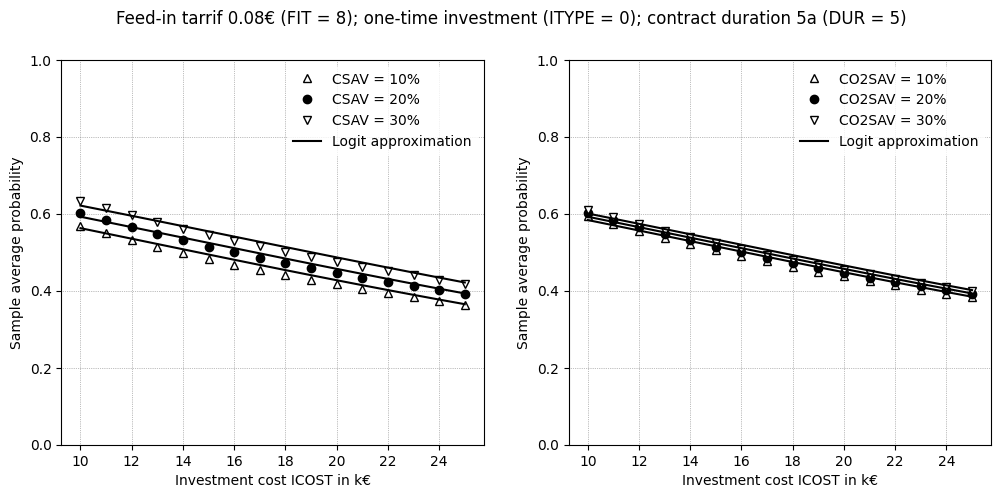

In [43]:
from phdtools.plots.consumer_preferences import plot_sample_average_choice_probability

_ = plot_sample_average_choice_probability(
    fname_mxl_csav=DataID(DataType.FIGURE, Chapter.METHODS, 6).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_mxl_sample_avg_prob_csav_rommel2017.csv",
    fname_mxl_co2sav=DataID(DataType.FIGURE, Chapter.METHODS, 6).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_mxl_sample_avg_prob_co2sav_rommel2017.csv",
    fname_logit_csav=DataID(DataType.FIGURE, Chapter.METHODS, 6).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_logit_sample_avg_prob_csav_rommel2017.csv",
    fname_logit_co2sav=DataID(DataType.FIGURE, Chapter.METHODS, 6).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_logit_sample_avg_prob_co2sav_rommel2017.csv",
)

## Oberst and Madlener, 2015: Prosumer Preferences Regarding the Adoption of Micro-Generation Technologies
[back](#Table-of-Contents)

In [44]:
# Image(filename=DATA_DIR / "oberst-madlener-2015" / "table_250615_table_6_Oberst_Madlener.png")

In [45]:
data = {
    "Description": [
        "Degree of electricity self-supply in %",
        "CO₂ reduction (50%)",
        "CO₂ reduction (100% or more)",
        "Social impacts (negative)",
        "Social impacts (positive)",
        "Net electricity costs in %",
        "Investment costs in 1000 Eur",
        "Payback period in years",
        "Investment risks (loss probability 0.1%)",
        "Investment risks (loss probability 10.0%)",
    ],
    "Model 2.0": [
        0.265 / 20,
        0.153,
        0.32,
        -0.392,
        0.23,
        -1.353 / 90,
        -1.169 / 20,
        -0.498 / 10,
        0.268,
        -0.48,
    ],
}

parameters = pd.DataFrame(data)

In [46]:
data = {
    "Description": [
        "Degree of electricity self-supply in %",
        "CO₂ reduction (50%)",
        "CO₂ reduction (100% or more)",
        "Social impacts (negative)",
        "Social impacts (positive)",
        "Net electricity costs in %",
        "Investment costs in 1000 Eur",
        "Payback period in years",
        "Investment risks (loss probability 0.1%)",
        "Investment risks (loss probability 10.0%)",
    ],
    "CHP": [50.0, 0.0, 0.0, 0.0, 0.0, 80.0, 20.0, 10.0, 1.0, 0.0],
    "Status quo": [0.0, 0.0, 0.0, 0.0, 0.0, 100.0, 0.0, 0.0, 1.0, 0.0],
}

attributes = pd.DataFrame(data)
attributes

,Description,CHP,Status quo
0,Degree of electricity self-supply in %,50.0,0.0
1,CO₂ reduction (50%),0.0,0.0
2,CO₂ reduction (100% or more),0.0,0.0
3,Social impacts (negative),0.0,0.0
4,Social impacts (positive),0.0,0.0
5,Net electricity costs in %,80.0,100.0
6,Investment costs in 1000 Eur,20.0,0.0
7,Payback period in years,10.0,0.0
8,Investment risks (loss probability 0.1%),1.0,1.0
9,Investment risks (loss probability 10.0%),0.0,0.0


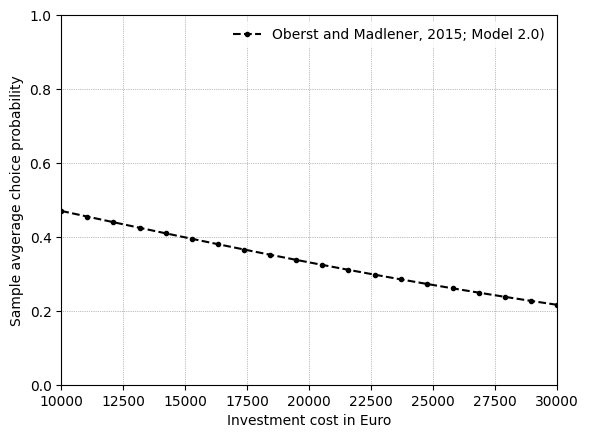

In [47]:
import matplotlib.pyplot as plt
import phdtools.plots


def choice_prob_oberst(attributes=attributes, parameters=parameters):
    x1 = attributes["CHP"].to_numpy()
    x2 = attributes["Status quo"].to_numpy()

    b = parameters["Model 2.0"].to_numpy()

    V1 = np.sum(b * x1)
    V2 = np.sum(b * x2)

    Pr = np.exp(V1) / (np.exp(V1) + np.exp(V2))
    return Pr


icost = np.linspace(10, 30, 20)
probability = np.zeros(icost.shape)

for i, c in enumerate(icost):
    attributes.iloc[6, 1] = c
    probability[i] = choice_prob_oberst(attributes=attributes, parameters=parameters)

fig, ax = plt.subplots(1, 1)
_ = ax.plot(
    icost * 1000, probability, ".--", label="Oberst and Madlener, 2015; Model 2.0)"
)

_ = ax.set_xlabel(r"Investment cost in Euro")
_ = ax.set_ylabel(r"Sample avgerage choice probability")
_ = ax.legend()

_ = ax.set_xlim(1e3 * icost.min(), 1e3 * icost.max())
_ = ax.set_ylim(0, 1)
_ = ax.grid(True)

## References
[back](#Table-of-contents)

Rommel, K. and Sagebiel, J. (2017) ‘Preferences for micro-cogeneration in Germany: Policy implications for grid expansion from a discrete choice experiment’, Applied Energy, 206, pp. 612–622. Available at: https://doi.org/10.1016/j.apenergy.2017.08.216.

Oberst, C. and Madlener, R. (2015) ‘Prosumer Preferences Regarding the Adoption of Micro-Generation Technologies: Empirical Evidence for German Homeowners’, SSRN Electronic Journal [Preprint]. Available at: https://doi.org/10.2139/ssrn.2670035.